In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

path = r"C:\Users\omar\The-64-Copy-Problem-BA26\Dataset\xxz_public_train.npz"

data = np.load(path, allow_pickle=True)

print("Files inside NPZ:")
print(data.files)
print("\n" + "="*60)
print("DATASET INFORMATION")
print("="*60)

for key in data.files:
    x = data[key]

    print(f"\n{key}")
    print("  Type :", type(x))
    print("  Shape:", x.shape)
    print("  Dtype:", x.dtype)

    if x.ndim == 1:
        print("  First values:", x[:100])

Files inside NPZ:
['states', 'ids', 'deltas', 'labels', 'num_qubits', 'model', 'convention']

DATASET INFORMATION

states
  Type : <class 'numpy.ndarray'>
  Shape: (48, 65536)
  Dtype: float32

ids
  Type : <class 'numpy.ndarray'>
  Shape: (48,)
  Dtype: <U3
  First values: ['T00' 'T01' 'T02' 'T03' 'T04' 'T05' 'T06' 'T07' 'T08' 'T09' 'T10' 'T11'
 'T12' 'T13' 'T14' 'T15' 'T16' 'T17' 'T18' 'T19' 'T20' 'T21' 'T22' 'T23'
 'T24' 'T25' 'T26' 'T27' 'T28' 'T29' 'T30' 'T31' 'T32' 'T33' 'T34' 'T35'
 'T36' 'T37' 'T38' 'T39' 'T40' 'T41' 'T42' 'T43' 'T44' 'T45' 'T46' 'T47']

deltas
  Type : <class 'numpy.ndarray'>
  Shape: (48,)
  Dtype: float64
  First values: [-2.5        -2.40769231 -2.31538462 -2.22307692 -2.13076923 -2.03846154
 -1.94615385 -1.85384615 -1.76153846 -1.66923077 -1.57692308 -1.48461538
 -1.39230769 -1.3        -0.7        -0.62631579 -0.55263158 -0.47894737
 -0.40526316 -0.33157895 -0.25789474 -0.18421053 -0.11052632 -0.03684211
  0.03684211  0.11052632  0.18421053  0.25789474  0

In [2]:
states = data["states"]
ids = data["ids"]
deltas = data["deltas"]
labels = data["labels"]
model= data["model"]
n = int(data["num_qubits"])
print("Number of states:", len(states))
print("Number of qubits:", n)
print("State dimension:", states.shape[1])

print("\nFirst 10 training states:")
print("-"*60)

for i in range(min(100, len(states))):
    print(
        f"{i:2d} | "
        f"ID = {ids[i]} | "
        f"D = {deltas[i]:.6f} | "
        f"model = {deltas[i]:.6f} | "
        f"Label = {labels[i]}"
        
    )

Number of states: 48
Number of qubits: 16
State dimension: 65536

First 10 training states:
------------------------------------------------------------
 0 | ID = T00 | D = -2.500000 | model = -2.500000 | Label = FM
 1 | ID = T01 | D = -2.407692 | model = -2.407692 | Label = FM
 2 | ID = T02 | D = -2.315385 | model = -2.315385 | Label = FM
 3 | ID = T03 | D = -2.223077 | model = -2.223077 | Label = FM
 4 | ID = T04 | D = -2.130769 | model = -2.130769 | Label = FM
 5 | ID = T05 | D = -2.038462 | model = -2.038462 | Label = FM
 6 | ID = T06 | D = -1.946154 | model = -1.946154 | Label = FM
 7 | ID = T07 | D = -1.853846 | model = -1.853846 | Label = FM
 8 | ID = T08 | D = -1.761538 | model = -1.761538 | Label = FM
 9 | ID = T09 | D = -1.669231 | model = -1.669231 | Label = FM
10 | ID = T10 | D = -1.576923 | model = -1.576923 | Label = FM
11 | ID = T11 | D = -1.484615 | model = -1.484615 | Label = FM
12 | ID = T12 | D = -1.392308 | model = -1.392308 | Label = FM
13 | ID = T13 | D = -1.30000

In [3]:
unique, counts = np.unique(labels, return_counts=True)

print("\nClass distribution:")
for label, count in zip(unique, counts):
    print(f"{label:5s}: {count}")


Class distribution:
FM   : 14
NEEL : 14
XY   : 20


In [4]:
print("\nD parameter:")
print("Minimum D:", deltas.min())
print("Maximum D:", deltas.max())

print("\nAll D values:")
print(np.sort(deltas))


D parameter:
Minimum D: -2.5
Maximum D: 2.5

All D values:
[-2.5        -2.40769231 -2.31538462 -2.22307692 -2.13076923 -2.03846154
 -1.94615385 -1.85384615 -1.76153846 -1.66923077 -1.57692308 -1.48461538
 -1.39230769 -1.3        -0.7        -0.62631579 -0.55263158 -0.47894737
 -0.40526316 -0.33157895 -0.25789474 -0.18421053 -0.11052632 -0.03684211
  0.03684211  0.11052632  0.18421053  0.25789474  0.33157895  0.40526316
  0.47894737  0.55263158  0.62631579  0.7         1.3         1.39230769
  1.48461538  1.57692308  1.66923077  1.76153846  1.85384615  1.94615385
  2.03846154  2.13076923  2.22307692  2.31538462  2.40769231  2.5       ]


In [5]:
i = 0

state = states[i]

print("State ID:", ids[i])
print("D:", deltas[i])
print("Label:", labels[i])

print("\nState shape:", state.shape)
print("First 20 amplitudes:")
print(state[:36])

print("\nMin amplitude:", state.min())
print("Max amplitude:", state.max())
print("Mean:", state.mean())
print("Std:", state.std())

print("\nNorm squared:", np.sum(state**2))

State ID: T00
D: -2.5
Label: FM

State shape: (65536,)
First 20 amplitudes:
[ 1.0000000e+00  3.0225787e-13  5.2080730e-13  1.4121251e-13
 -1.0204411e-12 -1.5131878e-13  7.8780834e-14  6.9639417e-14
  9.9986458e-13  1.9409767e-13 -9.9839272e-14 -4.4384028e-14
  8.9306587e-14  3.7761434e-14 -5.6007047e-15 -3.7646217e-14
 -6.3340934e-13 -1.2018216e-13  8.9992263e-14  7.8707846e-14
 -1.6118960e-15 -1.7857111e-14 -9.5679300e-15 -1.6295017e-14
 -2.3272093e-13 -1.0288965e-14 -1.6985423e-14  2.3843499e-15
  5.7699017e-14 -8.5264895e-15  2.2124289e-14  8.2489788e-14
  1.1068464e-12 -3.3607950e-14  2.2717004e-15 -8.4323038e-14]

Min amplitude: -1.6491877e-12
Max amplitude: 1.0
Mean: 1.5258789e-05
Std: 0.00390622

Norm squared: 1.0


saved q1_diagnostics.png


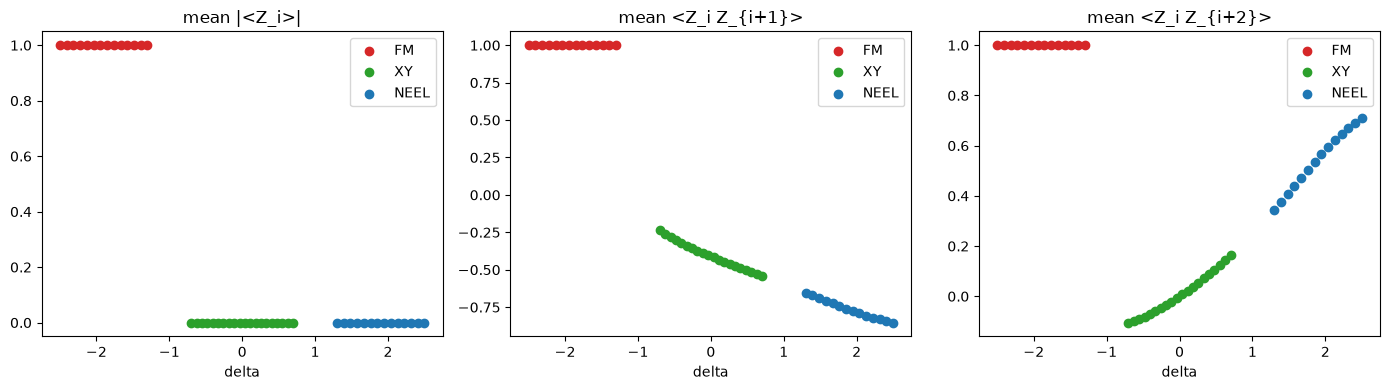

In [6]:
def bit_spins(n):
    """All 2^n basis strings, as +-1 spins. spins[k, i] = spin of qubit i in basis state k."""
    idx = np.arange(2**n)
    bits = (idx[:, None] >> np.arange(n)[None, ::-1]) & 1
    return 1 - 2 * bits.astype(float)   # |0> = +1, |1> = -1

SPINS = bit_spins(n)   # (65536, 16) — computed once, reused for every state

def exact_stats(vec):
    """Given one state vector, return (mean |Z_i>, corr NN, corr NNN)."""
    probs = np.abs(vec) ** 2
    mean_Z = probs @ SPINS                              # (n,)  <Z_i> per qubit
    nn_prod  = SPINS[:, :-1] * SPINS[:, 1:]              # (2^n, n-1)
    nnn_prod = SPINS[:, :-2] * SPINS[:, 2:]              # (2^n, n-2)
    corr_nn  = probs @ nn_prod
    corr_nnn = probs @ nnn_prod
    return mean_Z, corr_nn, corr_nnn

# Aggregate a single summary number per state for a first look:
mag        = np.zeros(len(states))   # average |<Z_i>| across the chain
avg_corr_nn  = np.zeros(len(states))
avg_corr_nnn = np.zeros(len(states))

for k, vec in enumerate(states):
    mZ, cnn, cnnn = exact_stats(vec.astype(np.complex128))
    mag[k] = np.mean(np.abs(mZ))
    avg_corr_nn[k]  = np.mean(cnn)
    avg_corr_nnn[k] = np.mean(cnnn)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, y, title in zip(
    axes, [mag, avg_corr_nn, avg_corr_nnn],
    ["mean |<Z_i>|", "mean <Z_i Z_{i+1}>", "mean <Z_i Z_{i+2}>"]
):
    for lab, color in zip(["FM", "XY", "NEEL"], ["tab:red", "tab:green", "tab:blue"]):
        m = labels == lab
        ax.scatter(deltas[m], y[m], label=lab, color=color)
    ax.set_xlabel("delta"); ax.set_title(title); ax.legend()
plt.tight_layout()
plt.savefig("q1_diagnostics.png", dpi=120)
print("saved q1_diagnostics.png")

In [20]:
from itertools import product

feats = np.stack([mag, avg_corr_nn, avg_corr_nnn], axis=1)

def nearest_centroid_accuracy(feats, labels):
    classes = ["FM", "XY", "NEEL"]
    centroids = {c: feats[labels == c].mean(axis=0) for c in classes}
    preds = []
    for f in feats:
        preds.append(min(classes, key=lambda c: np.linalg.norm(f - centroids[c])))
    return np.mean(np.array(preds) == labels), centroids

acc, centroids = nearest_centroid_accuracy(feats, labels)
print(f"Nearest-centroid accuracy from 3 simple Z-statistics: {acc:.2f}")

Nearest-centroid accuracy from 3 simple Z-statistics: 1.00


Fermi-Hubbard state dim: 65536 expected: 65536
saved q4_hamming_weight.png


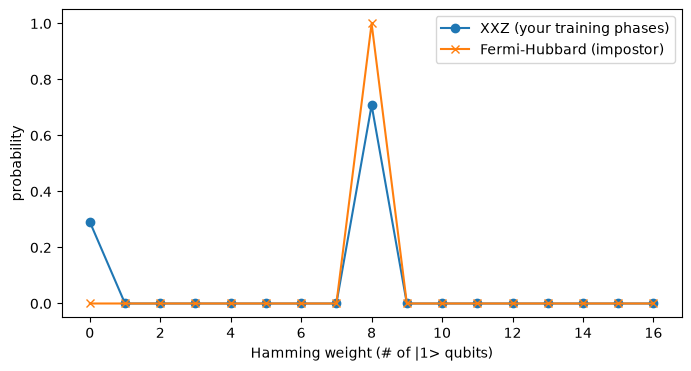

In [21]:
import pennylane as qml

fh_dataset = qml.data.load(
    "qspin", sysname="FermiHubbard", periodicity="open",
    lattice="chain", layout=(1, 8)
)[0]
fh_states = np.array(fh_dataset.ground_states)   # should be (100, 65536) if 16 qubits total
print("Fermi-Hubbard state dim:", fh_states.shape[1], "expected:", 2**n)

def hamming_weight_dist(vec, n):
    """Probability-weighted distribution over number of |1> bits."""
    probs = np.abs(vec) ** 2
    idx = np.arange(2**n)
    weights = bin_count = np.array([bin(k).count("1") for k in idx])
    hist = np.zeros(n + 1)
    for w in range(n + 1):
        hist[w] = probs[weights == w].sum()
    return hist

# Average Hamming-weight distribution across all XXZ training states
xxz_hist = np.mean([hamming_weight_dist(v.astype(np.complex128), n) for v in states], axis=0)
fh_hist  = np.mean([hamming_weight_dist(v.astype(np.complex128), n) for v in fh_states[:10]], axis=0)  # 10 is enough to see the shape

plt.figure(figsize=(8, 4))
plt.plot(xxz_hist, label="XXZ (your training phases)", marker="o")
plt.plot(fh_hist, label="Fermi-Hubbard (impostor)", marker="x")
plt.xlabel("Hamming weight (# of |1> qubits)"); plt.ylabel("probability")
plt.legend(); plt.savefig("q4_hamming_weight.png", dpi=120)
print("saved q4_hamming_weight.png")

In [7]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
import sys
oracle_dir = os.path.dirname(r"c:\Users\omar\The-64-Copy-Problem-BA26\src\oracle.py")
sys.path.append(oracle_dir)
from oracle import CopyOracle

COPY_BUDGETS = [4, 8, 16, 32, 64]
TRAIN_SAMPLES_PER_STATE = 200   # unrestricted -- training states have no budget
N_FOLDS = 6
NOISE_P = 0.02

data = np.load(path, allow_pickle=True)
ids = np.array([str(x) for x in data["ids"]])
labels = np.array([str(x) for x in data["labels"]])
classes = ["FM", "XY", "NEEL"]

def gather_bits(oracle, sid, n_copies):
    """Draw n_copies raw measurement samples for one state id. Each row: length-16 0/1 vector."""
    out = []
    for _ in range(n_copies):
        out.append(oracle.measure(sid))
    return np.stack(out, axis=0)


def train_mlp(train_ids):
    """Build raw-bitstring training set from unrestricted training states, fit MLP."""
    oracle = CopyOracle(path, unlimited=True, noise_p=NOISE_P, seed=1)
    X, y = [], []
    for sid in train_ids:
        lab = labels[ids == sid][0]
        bits = gather_bits(oracle, sid, TRAIN_SAMPLES_PER_STATE)
        X.append(bits)
        y.extend([lab] * TRAIN_SAMPLES_PER_STATE)
    X = np.concatenate(X, axis=0)
    y = np.array(y)

    clf = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=0)
    clf.fit(X, y)
    return clf


def evaluate_at_budget(clf, test_ids, k, seed):
    """Budget-matched evaluation: exactly k fresh copies per held-out state."""
    oracle = CopyOracle(path, copy_budget=k, noise_p=NOISE_P, seed=seed)
    correct = 0
    for sid in test_ids:
        true_lab = labels[ids == sid][0]
        bits = gather_bits(oracle, sid, k)                  # (k, 16)
        proba = clf.predict_proba(bits)                     # (k, 3) per-copy class probs
        avg_proba = proba.mean(axis=0)                       # aggregate across the k copies
        pred = clf.classes_[np.argmax(avg_proba)]
        correct += int(pred == true_lab)
    return correct / len(test_ids)


# ---------------------------------------------------------------
# Stratified k-fold: each fold's states are fully held out from
# training, so evaluation never sees a state's own training copies.
# ---------------------------------------------------------------
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=0)
results = {k: [] for k in COPY_BUDGETS}

for fold, (train_idx, test_idx) in enumerate(skf.split(ids, labels)):
    train_ids = ids[train_idx]
    test_ids = ids[test_idx]

    clf = train_mlp(train_ids)

    for k in COPY_BUDGETS:
        acc = evaluate_at_budget(clf, test_ids, k, seed=100 + fold)
        results[k].append(acc)

print(f"{'k':>4} | {'mean acc':>10} | {'std':>6}")
for k in COPY_BUDGETS:
    accs = np.array(results[k])
    print(f"{k:>4} | {accs.mean():>10.3f} | {accs.std():>6.3f}")

   k |   mean acc |    std
   4 |      0.958 |  0.093
   8 |      0.896 |  0.086
  16 |      1.000 |  0.000
  32 |      0.979 |  0.047
  64 |      0.979 |  0.047
